In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore")

In [2]:
df = pd.read_csv('../data/bank_clean.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476.0,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184.0,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [1]:
TARGET = 'deposit'

In [3]:
#Закодируем бинарные признаки
binary_cols = ['default', 'housing', 'loan', 'deposit']

df[binary_cols] = (df[binary_cols] == 'yes').astype(int)

round(df[['default', 'housing', 'loan']].mean().sum(), 3)

np.float64(0.635)

In [4]:
#Так же закодируем категории
categorical_cols = [
    'job', 'marital', 'education',
    'default', 'housing', 'loan',
    'contact', 'month', 'poutcome'
]

df = pd.get_dummies(df, columns=categorical_cols)

In [5]:
df.head()

,age,balance,day,duration,campaign,pdays,previous,deposit,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343.0,5,1042,1,-1,0,1,True,False,...,False,False,True,False,False,False,False,False,False,True
1,56,45.0,5,1467,1,-1,0,1,True,False,...,False,False,True,False,False,False,False,False,False,True
2,41,1270.0,5,1389,1,-1,0,1,False,False,...,False,False,True,False,False,False,False,False,False,True
3,55,2476.0,5,579,1,-1,0,1,False,False,...,False,False,True,False,False,False,False,False,False,True
4,54,184.0,5,673,2,-1,0,1,True,False,...,False,False,True,False,False,False,False,False,False,True


Построим матрицу корреляции с 15 признаками

In [6]:
corr = df.corr()

top_features = (
    corr['deposit']
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

corr_top = df[top_features].corr()

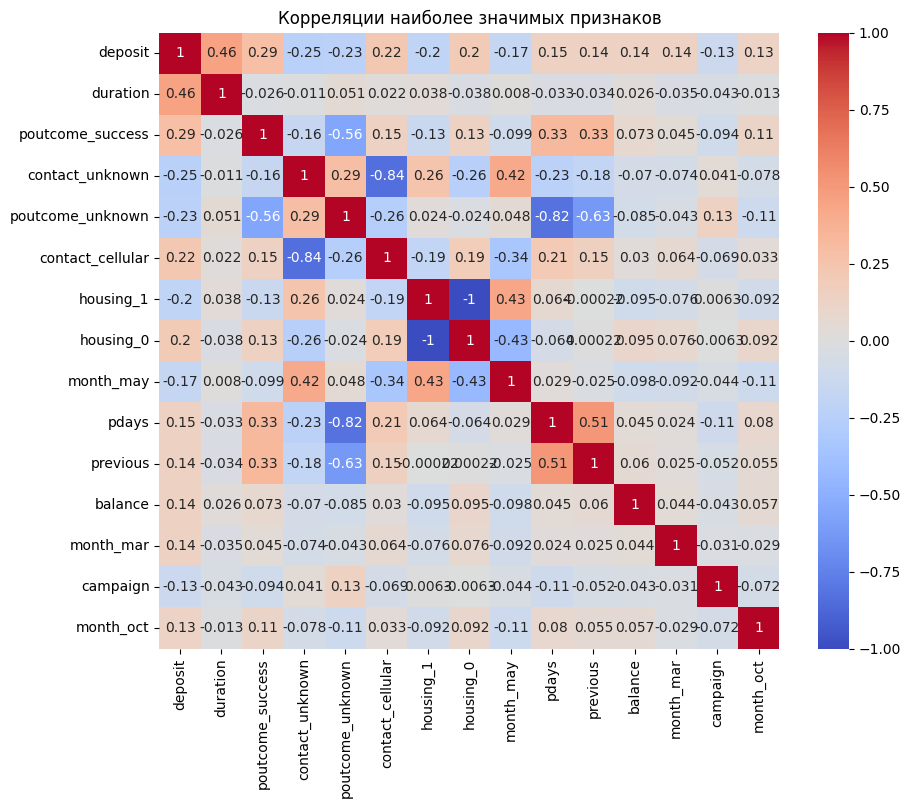

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_top,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Корреляции наиболее значимых признаков')
plt.show()

Есть отрицательные корреляции, но сильных корреляций не наблюдается

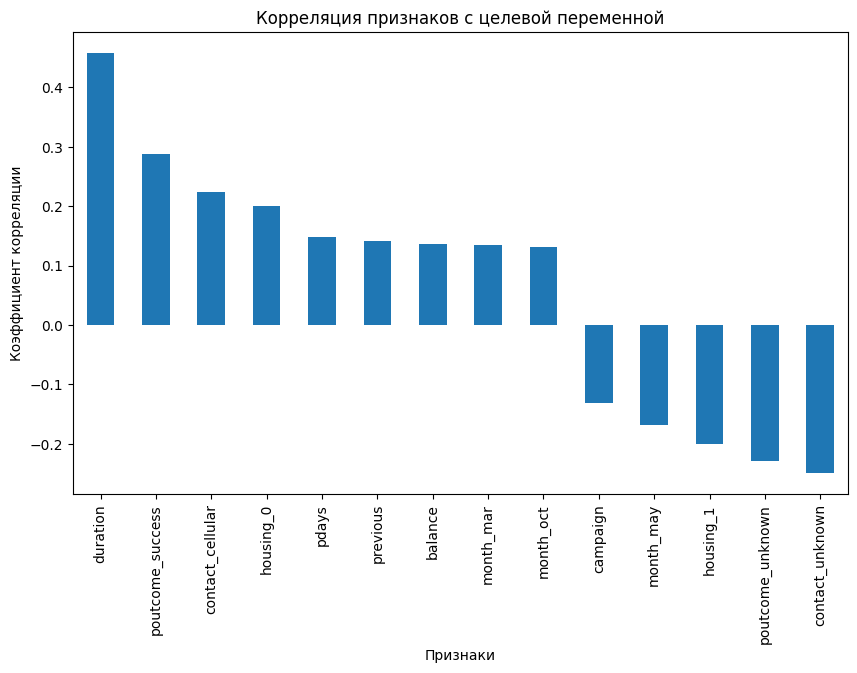

In [8]:
corr_with_target = corr_top['deposit'].sort_values(ascending=False)

plt.figure(figsize=(10,6))

corr_with_target.drop('deposit').plot(kind='bar')

plt.title('Корреляция признаков с целевой переменной')
plt.xlabel('Признаки')
plt.ylabel('Коэффициент корреляции')

plt.show()

Самый коррелируемый признак с таргетом - длительность разговора с клиентом, но есть один логичный момент, длительность разговора известна ***ПОСЛЕ*** разговора с клиентом,

 а нам надо, чтобы модель ориентировалась на клиентов ***ДО*** разговора с ним, значит признак ***длительности разговора*** будет ***утечкой данных***, его нужно удалить

In [9]:
df = df.drop(columns=['duration'])

In [10]:
df.to_csv('../data/bank_preprocessed.csv', index=False)